# Neural Network Model (PyTorch)

Training a deep learning model to predict flyability based on weather features.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
%matplotlib inline
sns.set_theme(style="whitegrid")
torch.manual_seed(42);

## 1. Data Preparation

In [10]:
df = pd.read_csv("../data/example/processed/multicell_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

train_df = df[df["year"] < 2025]
test_df = df[df["year"] == 2025]

drop_cols = ["date", "year", "flight_count", "is_flyable"]
X_train_raw = train_df.drop(columns=drop_cols).values.astype(np.float32)
y_train_raw = train_df["is_flyable"].values.astype(np.float32)
X_test_raw = test_df.drop(columns=drop_cols).values.astype(np.float32)
y_test_raw = test_df["is_flyable"].values.astype(np.float32)

# Standardization is crucial for Neural Networks
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Features: {X_train.shape[1]}")

Features: 36


## 2. PyTorch Dataset & Model

In [11]:
class FlyableDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(FlyableDataset(X_train, y_train_raw), batch_size=32, shuffle=True)
test_loader = DataLoader(FlyableDataset(X_test, y_test_raw), batch_size=32, shuffle=False)

class FlyNet(nn.Module):
    def __init__(self, input_dim):
        super(FlyNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

## 3. Training Loop

Using WEIGHTED loss (pos_weight=0.43)


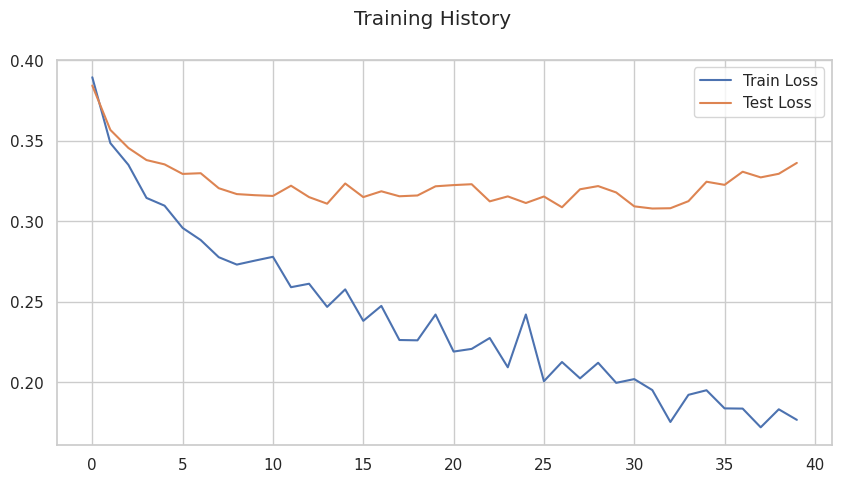

In [12]:
model = FlyNet(X_train.shape[1])

# Weighted loss to minimize false positives (safety first)
num_pos = y_train_raw.sum()
num_neg = len(y_train_raw) - num_pos
class_ratio = num_neg / num_pos
pos_weight = torch.tensor([class_ratio])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Using WEIGHTED loss (pos_weight={class_ratio:.2f})")

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 40
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        y_pred_test = model(torch.tensor(X_test))
        test_loss = criterion(y_pred_test, torch.tensor(y_test_raw).unsqueeze(1))
        
    train_losses.append(epoch_loss / len(train_loader))
    test_losses.append(test_loss.item())

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.suptitle("Training History")
plt.show()

## 4. Evaluation

=== Optimal Threshold Search (by Macro F1) ===
Best threshold: 0.55
Macro F1: 0.783
  F1 (Not Flyable): 0.725
  F1 (Flyable):     0.841

              precision    recall  f1-score   support

 Not Flyable       0.72      0.73      0.73        45
     Flyable       0.85      0.84      0.84        79

    accuracy                           0.80       124
   macro avg       0.78      0.78      0.78       124
weighted avg       0.80      0.80      0.80       124



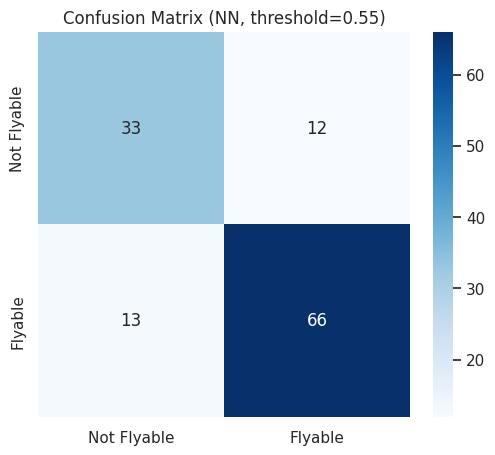

In [13]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test))
    probs = torch.sigmoid(logits).numpy()

# Optimal threshold search by Macro F1
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.1, 0.9, 0.01)
macro_f1_scores = []
f1_not_flyable = []
f1_flyable = []

for thresh in thresholds:
    y_pred_thresh = (probs > thresh).astype(float)
    p, r, f1, _ = precision_recall_fscore_support(y_test_raw, y_pred_thresh, zero_division=0)
    macro_f1 = (f1[0] + f1[1]) / 2  # Average of both classes
    macro_f1_scores.append(macro_f1)
    f1_not_flyable.append(f1[0])
    f1_flyable.append(f1[1])

best_idx = np.argmax(macro_f1_scores)
best_threshold = thresholds[best_idx]
best_macro_f1 = macro_f1_scores[best_idx]

print(f"=== Optimal Threshold Search (by Macro F1) ===")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Macro F1: {best_macro_f1:.3f}")
print(f"  F1 (Not Flyable): {f1_not_flyable[best_idx]:.3f}")
print(f"  F1 (Flyable):     {f1_flyable[best_idx]:.3f}")
print()

# Apply optimal threshold
preds = (probs > best_threshold).astype(float)
print(classification_report(y_test_raw, preds, target_names=["Not Flyable", "Flyable"]))

cm = confusion_matrix(y_test_raw, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Flyable", "Flyable"], yticklabels=["Not Flyable", "Flyable"])
plt.title(f"Confusion Matrix (NN, threshold={best_threshold:.2f})")
plt.show()

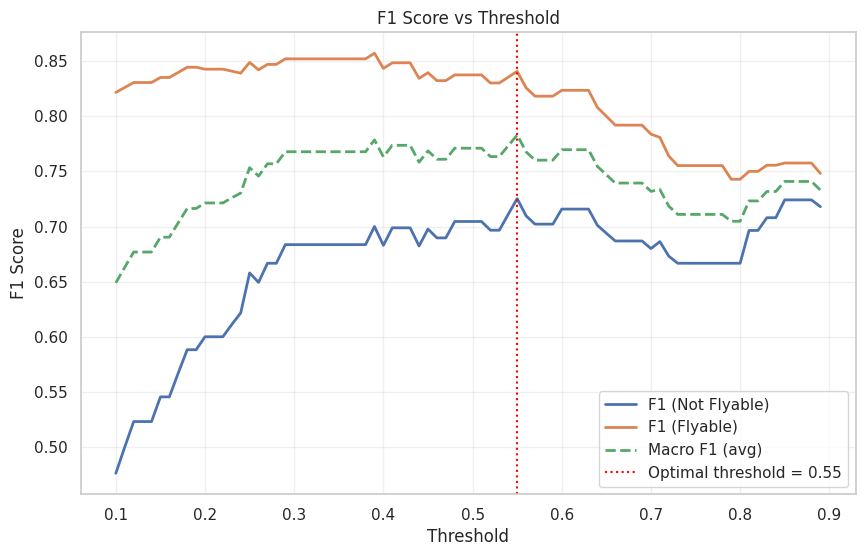

In [14]:
# Visualize threshold vs F1 scores
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_not_flyable, label="F1 (Not Flyable)", linewidth=2)
plt.plot(thresholds, f1_flyable, label="F1 (Flyable)", linewidth=2)
plt.plot(thresholds, macro_f1_scores, label="Macro F1 (avg)", linewidth=2, linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Optimal threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()